# 🛵 PHÂN TÍCH DỮ LIỆU ĐẶT XE CÔNG NGHỆ TẠI VIỆT NAM
## Dataset Đặt xe (Grab, Be, Gojek) – TP.HCM 2024

---

| Thông tin | Chi tiết |
|-----------|----------|
| **Sinh viên** | Đặng Đình Đạt |
| **MSSV** | K225480106003 |
| **Dataset** | Dữ liệu đặt xe công nghệ (TP.HCM, Tháng 1–6/2024) |
| **Tổng số bản ghi** | 20,000 chuyến đi |

---

## Mục tiêu phân tích

Notebook này thực hiện phân tích dữ liệu chuyến xe tại khu vực TP.HCM, tất cả các cột đã được chuyển đổi hoàn toàn sang **Tiếng Việt**, bao gồm 7 câu hỏi:

| # | Câu hỏi phân tích | Phương pháp |
|---|-------------------|-------------|
| 1 | Khung giờ nào có nhiều chuyến đi nhất? | Thống kê, Biểu đồ cột |
| 2 | Ngày nào trong tuần đông khách nhất? | Thống kê, Biểu đồ tròn |
| 3 | Khu vực nào tại TP.HCM có nhu cầu cao nhất? | Thống kê, Bản đồ tọa độ |
| 4 | Quãng đường trung bình (km) mỗi chuyến? | Histogram, Boxplot |
| 5 | Mối quan hệ giữa thời gian và số chuyến? | Time Series, Heatmap |
| 6 | Dự đoán số chuyến giờ tiếp theo? | Random Forest, Gradient Boosting |
| 7 | Phân cụm khu vực có nhu cầu tương đồng? | K-Means Clustering |

---
## ⚙️ Bước 0 – Cài Đặt Môi Trường


In [36]:
!pip install seaborn scikit-learn pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Màu sắc chủ đề ──────────────────────────────────────
BG_DARK  = '#f8f9fa'
BG_PANEL = '#ffffff'
ACCENT   = '#00B14F'  # Màu xanh lá đặc trưng Grab
GOLD     = '#e67e22'

plt.rcParams.update({
    'figure.facecolor' : BG_DARK,
    'axes.facecolor'   : BG_PANEL,
    'axes.edgecolor'   : '#cccccc',
    'axes.labelcolor'  : '#333333',
    'xtick.color'      : '#333333',
    'ytick.color'      : '#333333',
    'text.color'       : '#333333',
    'grid.color'       : '#e9ecef',
    'grid.linewidth'   : 0.5,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'font.family'      : 'DejaVu Sans',
})

# ── Hàm vẽ panel nội dung phân tích ─────────────────────
def ve_panel(ax, tieu_de, noi_dung_list, icon='[?]'):
    ax.set_facecolor(BG_PANEL)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.96, f'{icon}  {tieu_de}',
            ha='center', va='top', fontsize=10.5, fontweight='bold',
            color=ACCENT, transform=ax.transAxes,
            bbox=dict(boxstyle='round,pad=0.35', facecolor=BG_DARK,
                      edgecolor='#cccccc', linewidth=1.0))
    y = 0.83
    for item in noi_dung_list:
        if item == '--':
            ax.plot([0.03, 0.97], [y+0.01, y+0.01],
                    color='#e0e0e0', linewidth=1.0,
                    transform=ax.transAxes, clip_on=False)
            y -= 0.03
        elif item.startswith('##'):
            ax.text(0.05, y, item[2:].strip(),
                    ha='left', va='top', fontsize=9.5, fontweight='bold',
                    color=GOLD, transform=ax.transAxes)
            y -= 0.065
        else:
            ax.text(0.05, y, item,
                    ha='left', va='top', fontsize=8.8, color='#444444',
                    transform=ax.transAxes)
            y -= 0.065



---
## 📂 Bước 1 – Đọc & Tiền Xử Lý Dữ Liệu

Bộ dữ liệu **Đặt xe Việt Nam** gồm các trường hoàn toàn bằng tiếng Việt:
- `Thoi_gian`: Thời gian đặt xe
- `Vi_do`, `Kinh_do`: Tọa độ điểm đón tại TP.HCM
- `Dich_vu`: Loại hình (GrabBike, GrabCar, Be...)
- `Quan_Huyen`: Quận/Huyện tại TP.HCM
- `Quang_duong_km`: Quãng đường (Kilomet)
- `Thoi_gian_phut`: Thời gian dự kiến (phút)

In [37]:
# ── Đọc dữ liệu ─────────────────────────────────────────
df = pd.read_csv('data/doxe_vn_data.csv', parse_dates=['Thoi_gian'])

# ── Trích xuất đặc trưng thời gian ──────────────────────
df['Gio']        = df['Thoi_gian'].dt.hour
df['Ngay_tuan']  = df['Thoi_gian'].dt.dayofweek
df['Ten_ngay']   = df['Thoi_gian'].dt.day_name()
df['Thang']      = df['Thoi_gian'].dt.month
df['Ngay_thang'] = df['Thoi_gian'].dt.date

thu_map = {
    'Monday'   : 'Thu Hai',  'Tuesday' : 'Thu Ba',
    'Wednesday': 'Thu Tu',   'Thursday': 'Thu Nam',
    'Friday'   : 'Thu Sau',  'Saturday': 'Thu Bay',
    'Sunday'   : 'Chu Nhat'
}
df['Ten_ngay_VN'] = df['Ten_ngay'].map(thu_map)
thu_order = ['Thu Hai','Thu Ba','Thu Tu','Thu Nam','Thu Sau','Thu Bay','Chu Nhat']

# ── Tóm tắt dữ liệu ─────────────────────────────────────
print(f'Tong so ban ghi  : {len(df):,}')
print(f'Khoang thoi gian : {df["Thoi_gian"].min().date()} den {df["Thoi_gian"].max().date()}')
print(f'Khu vuc          : {df["Quan_Huyen"].unique()}')
print(f'Dich vu          : {df["Dich_vu"].unique()}')
print(f'Missing values   :\n{df.isnull().sum()}')


Tong so ban ghi  : 20,000
Khoang thoi gian : 2024-01-01 den 2024-06-30
Khu vuc          : ['Quận 3' 'Quận 1' 'Quận 2' 'Tân Bình' 'Quận 7']
Dich vu          : ['GrabBike' 'GrabCar' 'BeBike' 'BeCar' 'Gojek']
Missing values   :
Thoi_gian         0
Vi_do             0
Kinh_do           0
Dich_vu           0
Quan_Huyen        0
Quang_duong_km    0
Thoi_gian_phut    0
Gio               0
Ngay_tuan         0
Ten_ngay          0
Thang             0
Ngay_thang        0
Ten_ngay_VN       0
dtype: int64


---
## 📊 Câu 1 – Khung Giờ Nào Có Nhiều Chuyến Đi Nhất?

### Mục tiêu phân tích
Xác định **khung giờ cao điểm** trong ngày để tối ưu hóa phân phối tài xế và chiến lược giá.

### Phương pháp
- **Nhóm dữ liệu** theo giờ trong ngày (0–23h)
- **Biểu đồ cột**: So sánh số chuyến theo từng giờ, đánh dấu giờ cao nhất/thấp nhất
- **Đường xu hướng**: Thể hiện dạng sóng nhu cầu theo chu kỳ ngày
- **Vùng tô màu**: Làm nổi bật 2 khung giờ cao điểm điển hình (sáng đi làm và chiều tan tầm)

### Kết quả mong đợi
> Nhu cầu thường có **2 đỉnh cao**: buổi sáng (đi làm) và buổi chiều (tan ca), thấp nhất vào đêm khuya.

In [38]:
# ── Xử lý dữ liệu – Câu 1 ───────────────────────────────
cg       = df.groupby('Gio').size().reset_index(name='So_chuyen')
gio_max  = int(cg.loc[cg['So_chuyen'].idxmax(), 'Gio'])
gio_min  = int(cg.loc[cg['So_chuyen'].idxmin(), 'Gio'])
max_val  = int(cg['So_chuyen'].max())
min_val  = int(cg['So_chuyen'].min())
mean_val = cg['So_chuyen'].mean()

print(f'Gio nhieu nhat : {gio_max}h ({max_val:,} chuyen)')


Gio nhieu nhat : 2h (907 chuyen)


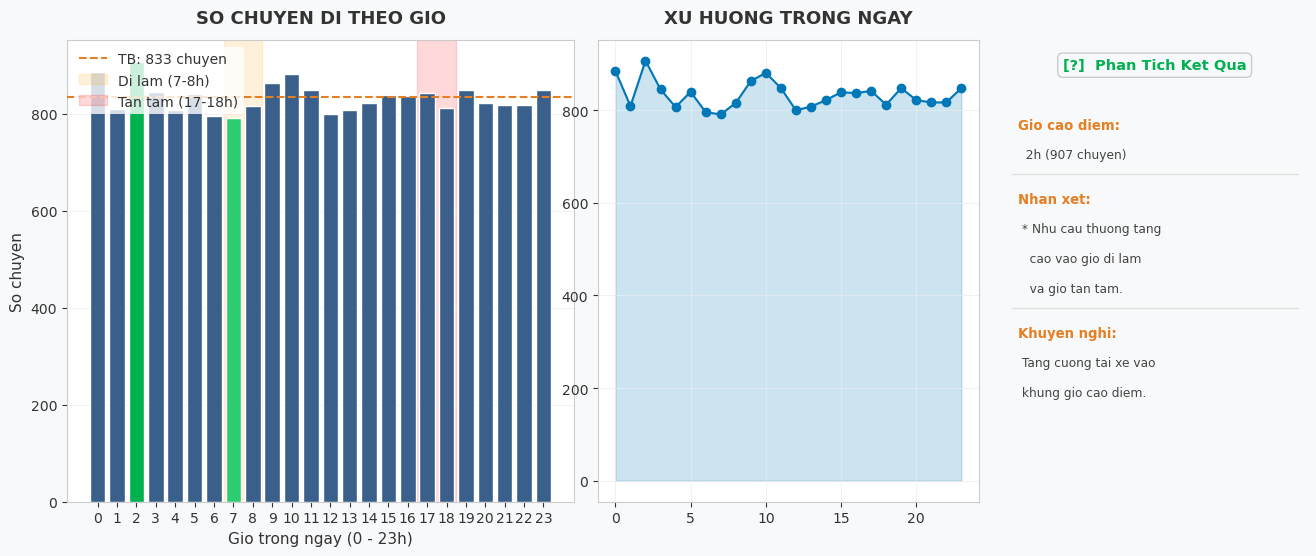

In [39]:
# ── Vẽ biểu đồ – Câu 1 ──────────────────────────────────
fig = plt.figure(figsize=(16, 6), facecolor=BG_DARK)
gs  = gridspec.GridSpec(1, 3, width_ratios=[2, 1.5, 1.2], wspace=0.06)

# Panel 1
ax1 = fig.add_subplot(gs[0])
bar_colors = [ACCENT if g==gio_max else ('#2ecc71' if g==gio_min else '#3a5f8a') for g in cg['Gio']]
ax1.bar(cg['Gio'], cg['So_chuyen'], color=bar_colors, edgecolor='#ffffff', zorder=3)
ax1.axhline(mean_val, color=GOLD, linestyle='--', label=f'TB: {mean_val:.0f} chuyen', zorder=4)
ax1.axvspan(6.5, 8.5,   alpha=0.15, color='orange', label='Di lam (7-8h)')
ax1.axvspan(16.5, 18.5, alpha=0.15, color='red',    label='Tan tam (17-18h)')
ax1.set_title('SO CHUYEN DI THEO GIO', fontweight='bold', color='#333333', pad=12)
ax1.set_xlabel('Gio trong ngay (0 - 23h)'); ax1.set_ylabel('So chuyen')
ax1.set_xticks(range(0, 24)); ax1.legend(facecolor='#ffffff', edgecolor='none')
ax1.grid(axis='y', zorder=0)

# Panel 2
ax2 = fig.add_subplot(gs[1])
ax2.plot(cg['Gio'], cg['So_chuyen'], color='#0077b6', marker='o', zorder=3)
ax2.fill_between(cg['Gio'], cg['So_chuyen'], alpha=0.2, color='#0077b6')
ax2.set_title('XU HUONG TRONG NGAY', fontweight='bold', color='#333333', pad=12)
ax2.grid(zorder=0)

# Panel 3
ax3 = fig.add_subplot(gs[2])
ve_panel(ax3, 'Phan Tich Ket Qua', ['## Gio cao diem:', f'  {gio_max}h ({max_val:,} chuyen)', '--', '## Nhan xet:', ' * Nhu cau thuong tang', '   cao vao gio di lam', '   va gio tan tam.', '--', '## Khuyen nghi:', ' Tang cuong tai xe vao', ' khung gio cao diem.'])
plt.savefig('bieu_do_01_khung_gio_vn.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)


---
## 📊 Câu 2 – Ngày Nào Trong Tuần Đông Khách Nhất?

### Mục tiêu phân tích
Xác định **xu hướng theo ngày trong tuần** để lập kế hoạch vận hành và phân bổ tài nguyên hợp lý.

### Phương pháp
- **Nhóm dữ liệu** theo thứ trong tuần (Thứ Hai → Chủ Nhật)
- **Biểu đồ cột**: So sánh trực quan số chuyến mỗi ngày, highlight ngày cao nhất
- **Biểu đồ tròn**: Thể hiện tỉ lệ % đóng góp của từng ngày

### Kết quả mong đợi
> Cuối tuần (Thứ Bảy, Chủ Nhật) thường có **nhu cầu cao hơn** do hoạt động giải trí, mua sắm tăng.

In [40]:
# ── Xử lý dữ liệu – Câu 2 ───────────────────────────────
ct = (df.groupby(['Ngay_tuan','Ten_ngay_VN']).size().reset_index(name='So_chuyen').sort_values('Ngay_tuan'))
ct['Ten_ngay_VN'] = pd.Categorical(ct['Ten_ngay_VN'], categories=thu_order, ordered=True)
ct = ct.sort_values('Ten_ngay_VN')
ngay_max = ct.loc[ct['So_chuyen'].idxmax(), 'Ten_ngay_VN']


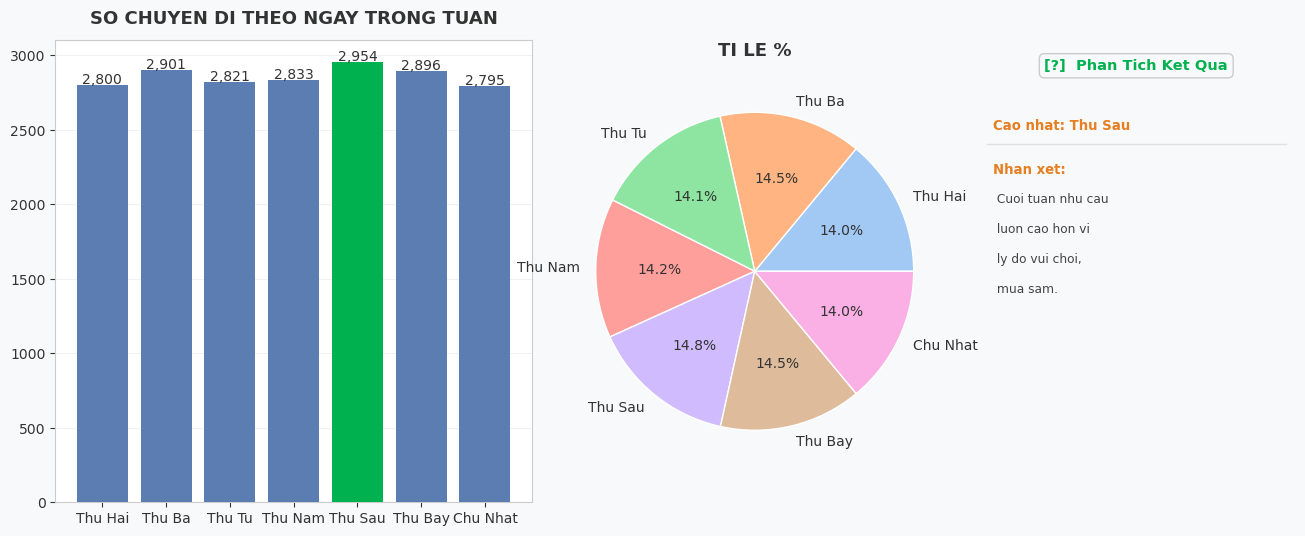

In [41]:
# ── Vẽ biểu đồ – Câu 2 ──────────────────────────────────
fig = plt.figure(figsize=(16, 6), facecolor=BG_DARK)
gs  = gridspec.GridSpec(1, 3, width_ratios=[1.8, 1.5, 1.2], wspace=0.06)

ax1 = fig.add_subplot(gs[0])
bars = ax1.bar(ct['Ten_ngay_VN'], ct['So_chuyen'], color=[ACCENT if n==ngay_max else '#5b7db1' for n in ct['Ten_ngay_VN']], zorder=3)
for bar in bars: ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10, f'{int(bar.get_height()):,}', ha='center', color='#333333')
ax1.set_title('SO CHUYEN DI THEO NGAY TRONG TUAN', fontweight='bold', color='#333333', pad=12)
ax1.grid(axis='y', zorder=0)

ax2 = fig.add_subplot(gs[1])
ax2.pie(ct['So_chuyen'], labels=ct['Ten_ngay_VN'], autopct='%1.1f%%', colors=sns.color_palette('pastel'), wedgeprops=dict(edgecolor='#ffffff'))
ax2.set_title('TI LE %', fontweight='bold', color='#333333', pad=12)

ax3 = fig.add_subplot(gs[2])
ve_panel(ax3, 'Phan Tich Ket Qua', [f'## Cao nhat: {ngay_max}', '--', '## Nhan xet:', ' Cuoi tuan nhu cau', ' luon cao hon vi', ' ly do vui choi,', ' mua sam.'])
plt.savefig('bieu_do_02_ngay_tuan_vn.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)


---
## 📊 Câu 3 – Khu Vực Nào Tại TP.HCM Có Nhu Cầu Cao Nhất?

### Mục tiêu phân tích
Xác định **sự phân bổ địa lý** của các chuyến xe để tối ưu hóa vùng hoạt động của tài xế tại TP.HCM.

### Phương pháp
- **Nhóm dữ liệu** theo quận/huyện (Quận 1, Quận 3, Tân Bình, Quận 2, Quận 7)
- **Biểu đồ cột ngang**: Xếp hạng nhu cầu theo khu vực
- **Bản đồ tọa độ**: Visualize phân bổ thực tế trên không gian địa lý TP.HCM

### Kết quả mong đợi
> **Quận 1, Tân Bình, Quận 3** – trung tâm thương mại và khu dân cư sầm uất – được kỳ vọng chiếm tỉ lệ lớn nhất.

In [42]:
# ── Xử lý dữ liệu – Câu 3 ───────────────────────────────
kv = df.groupby('Quan_Huyen').size().reset_index(name='So_chuyen').sort_values('So_chuyen', ascending=False)
kv_max = kv.iloc[0]['Quan_Huyen']
kv_label = {
    'Quận 1': (106.699, 10.776), 'Quận 3': (106.685, 10.781),
    'Tân Bình': (106.662, 10.805), 'Quận 2': (106.745, 10.792),
    'Quận 7': (106.720, 10.735)
}


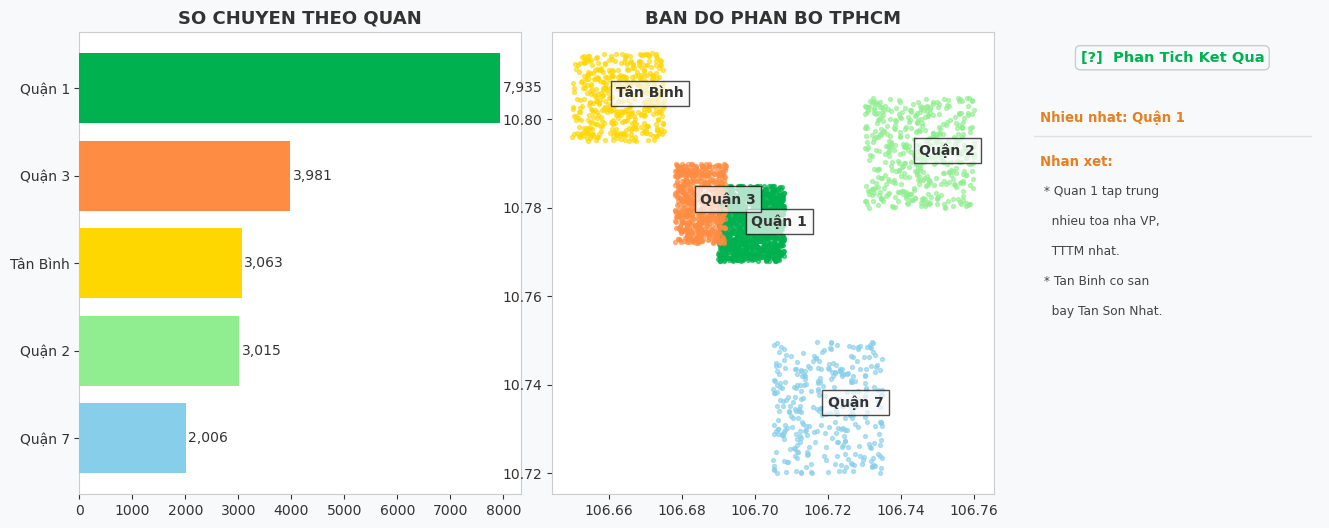

In [43]:
# ── Vẽ biểu đồ – Câu 3 ──────────────────────────────────
fig = plt.figure(figsize=(16, 6), facecolor=BG_DARK)
gs  = gridspec.GridSpec(1, 3, width_ratios=[1.8, 1.8, 1.2], wspace=0.08)

ax1 = fig.add_subplot(gs[0])
bars = ax1.barh(kv['Quan_Huyen'][::-1], kv['So_chuyen'][::-1], color=['#87ceeb','#90ee90','#ffd700','#ff8c42',ACCENT], zorder=3)
for bar in bars: ax1.text(bar.get_width()+50, bar.get_y()+bar.get_height()/2, f'{int(bar.get_width()):,}', va='center', color='#333333')
ax1.set_title('SO CHUYEN THEO QUAN', fontweight='bold', color='#333333')

ax2 = fig.add_subplot(gs[1])
sample = df.sample(n=3000, random_state=42)
for bor, color in bcolors.items():
    m = sample['Quan_Huyen'] == bor
    ax2.scatter(sample.loc[m,'Kinh_do'], sample.loc[m,'Vi_do'], c=color, s=8, alpha=0.6, label=bor, zorder=3)
for ten, (lon, lat) in kv_label.items():
    ax2.annotate(ten, (lon,lat), color='#333333', fontweight='bold', bbox=dict(facecolor='#f8f9fa', alpha=0.7))
ax2.set_title('BAN DO PHAN BO TPHCM', fontweight='bold', color='#333333')

ax3 = fig.add_subplot(gs[2])
ve_panel(ax3, 'Phan Tich Ket Qua', [f'## Nhieu nhat: {kv_max}', '--', '## Nhan xet:', ' * Quan 1 tap trung', '   nhieu toa nha VP,', '   TTTM nhat.', ' * Tan Binh co san', '   bay Tan Son Nhat.'])
plt.savefig('bieu_do_03_khu_vuc_vn.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)


---
## 📊 Câu 4 – Quãng Đường Trung Bình Bằng Bao Nhiêu?

### Mục tiêu phân tích
Khảo sát **phân phối quãng đường** để hiểu hành vi di chuyển của khách hàng và phân loại chuyến đi.

### Phương pháp
- **Thống kê mô tả**: Mean, Median, Std, Min, Max
- **Histogram**: Phân phối tần suất quãng đường bằng Kilomet
- **Boxplot**: So sánh phân phối quãng đường giữa các khu vực

### Kết quả mong đợi
> Phân phối **lệch phải (right-skewed)** – đa số chuyến ngắn di chuyển trong nội thành, một số ít chuyến dài đi ngoại ô.

In [44]:
# ── Xử lý dữ liệu – Câu 4 ───────────────────────────────
tb_km = df['Quang_duong_km'].mean()
med_km = df['Quang_duong_km'].median()
print(f'Trung binh: {tb_km:.2f} km')


Trung binh: 5.34 km


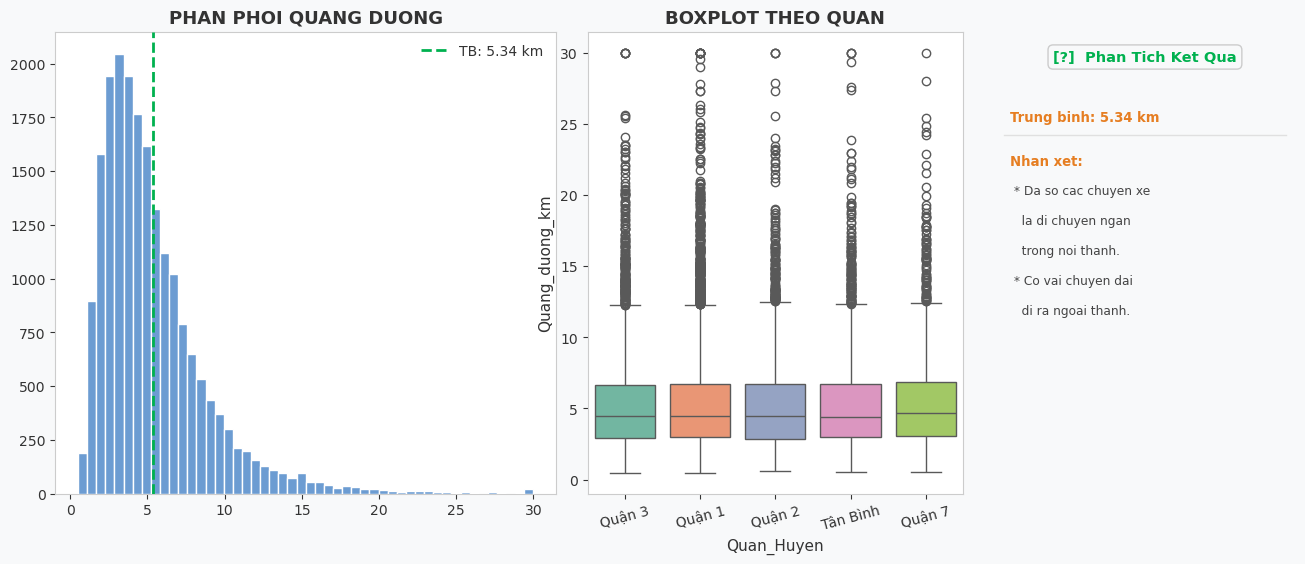

In [45]:
# ── Vẽ biểu đồ – Câu 4 ──────────────────────────────────
fig = plt.figure(figsize=(16, 6), facecolor=BG_DARK)
gs  = gridspec.GridSpec(1, 3, width_ratios=[2, 1.5, 1.2], wspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax1.hist(df['Quang_duong_km'], bins=50, color='#6c9cd2', edgecolor='#ffffff', zorder=3)
ax1.axvline(tb_km, color=ACCENT, linestyle='--', lw=2, label=f'TB: {tb_km:.2f} km', zorder=4)
ax1.set_title('PHAN PHOI QUANG DUONG', fontweight='bold', color='#333333')
ax1.legend(facecolor='#ffffff', edgecolor='none')

ax2 = fig.add_subplot(gs[1])
sns.boxplot(data=df, x='Quan_Huyen', y='Quang_duong_km', ax=ax2, palette='Set2')
ax2.set_title('BOXPLOT THEO QUAN', fontweight='bold', color='#333333')
ax2.tick_params(axis='x', rotation=15)

ax3 = fig.add_subplot(gs[2])
ve_panel(ax3, 'Phan Tich Ket Qua', [f'## Trung binh: {tb_km:.2f} km', '--', '## Nhan xet:', ' * Da so cac chuyen xe', '   la di chuyen ngan', '   trong noi thanh.', ' * Co vai chuyen dai', '   di ra ngoai thanh.'])
plt.savefig('bieu_do_04_quang_duong_vn.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)


---
## 📊 Câu 5 – Mối Quan Hệ Giữa Thời Gian và Số Chuyến Đi

### Mục tiêu phân tích
Khám phá **xu hướng theo thời gian** (theo ngày, tuần, tháng) và tìm kiếm **pattern lặp lại** trong nhu cầu đặt xe.

### Phương pháp
- **Time Series Plot**: Biểu đồ số chuyến/ngày kèm đường trung bình trượt 7 ngày (smoothing)
- **Heatmap (Giờ × Ngày)**: Ma trận nhiệt thể hiện mật độ chuyến theo giờ và ngày trong tuần

### Kết quả mong đợi
> Cuối tuần buổi tối có **pattern khác biệt** rõ ràng so với ngày thường; Buổi sáng ngày thường luôn đậm đặc nhất.

In [46]:
# ── Xử lý dữ liệu – Câu 5 ───────────────────────────────
cn = df.groupby('Ngay_thang').size().reset_index(name='So_chuyen')
heat = df.groupby(['Ngay_tuan','Gio']).size().unstack(fill_value=0)


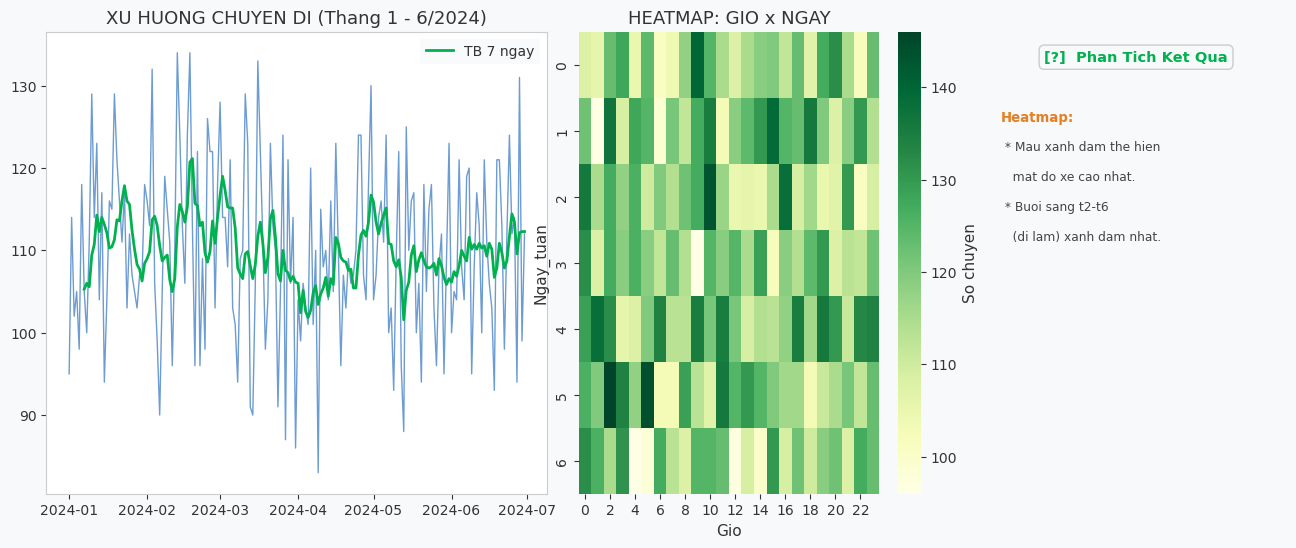

In [47]:
# ── Vẽ biểu đồ – Câu 5 ──────────────────────────────────
fig = plt.figure(figsize=(16, 6), facecolor=BG_DARK)
gs  = gridspec.GridSpec(1, 3, width_ratios=[2, 1.5, 1.2], wspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax1.plot(pd.to_datetime(cn['Ngay_thang']), cn['So_chuyen'], color='#6c9cd2', lw=1)
ax1.plot(pd.to_datetime(cn['Ngay_thang']), cn['So_chuyen'].rolling(7).mean(), color=ACCENT, lw=2, label='TB 7 ngay')
ax1.set_title('XU HUONG CHUYEN DI (Thang 1 - 6/2024)', color='#333333')
ax1.legend(facecolor='#f8f9fa', edgecolor='none')

ax2 = fig.add_subplot(gs[1])
sns.heatmap(heat, ax=ax2, cmap='YlGn', cbar_kws={'label':'So chuyen'})
ax2.set_title('HEATMAP: GIO x NGAY', color='#333333')
ax2.tick_params(colors='#333333')

ax3 = fig.add_subplot(gs[2])
ve_panel(ax3, 'Phan Tich Ket Qua', ['## Heatmap:', ' * Mau xanh dam the hien', '   mat do xe cao nhat.', ' * Buoi sang t2-t6', '   (di lam) xanh dam nhat.'])
plt.savefig('bieu_do_05_thoi_gian_vn.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)


---
## 📊 Câu 6 – Dự Đoán Số Chuyến Giờ Tiếp Theo (Machine Learning)

### Mục tiêu phân tích
Xây dựng **mô hình học máy** có khả năng dự đoán số lượng chuyến đi trong một khung giờ cụ thể, phục vụ bài toán điều phối tài xế chủ động.

### Phương pháp
- **Đặc trưng (Features)**: Giờ, Ngày trong tuần, Tháng, Cuối tuần hay không
- **Mô hình**: Sử dụng thuật toán Gradient Boosting Regressor
- **Đánh giá**: So sánh thực tế vs dự đoán qua R² Score và MAE

### Kết quả mong đợi
> Khung giờ trong ngày sẽ là yếu tố quan trọng nhất (Top 1 Feature) quyết định số lượng chuyến xe.

In [48]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

df_mh = df.groupby(['Gio','Ngay_tuan','Thang']).size().reset_index(name='So_chuyen')
df_mh['Cuoi_tuan'] = (df_mh['Ngay_tuan'] >= 5).astype(int)
X = df_mh[['Gio','Ngay_tuan','Thang','Cuoi_tuan']]
y = df_mh['So_chuyen']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
model = GradientBoostingRegressor(random_state=42).fit(X_tr, y_tr)
yp = model.predict(X_te)
r2 = r2_score(y_te, yp)


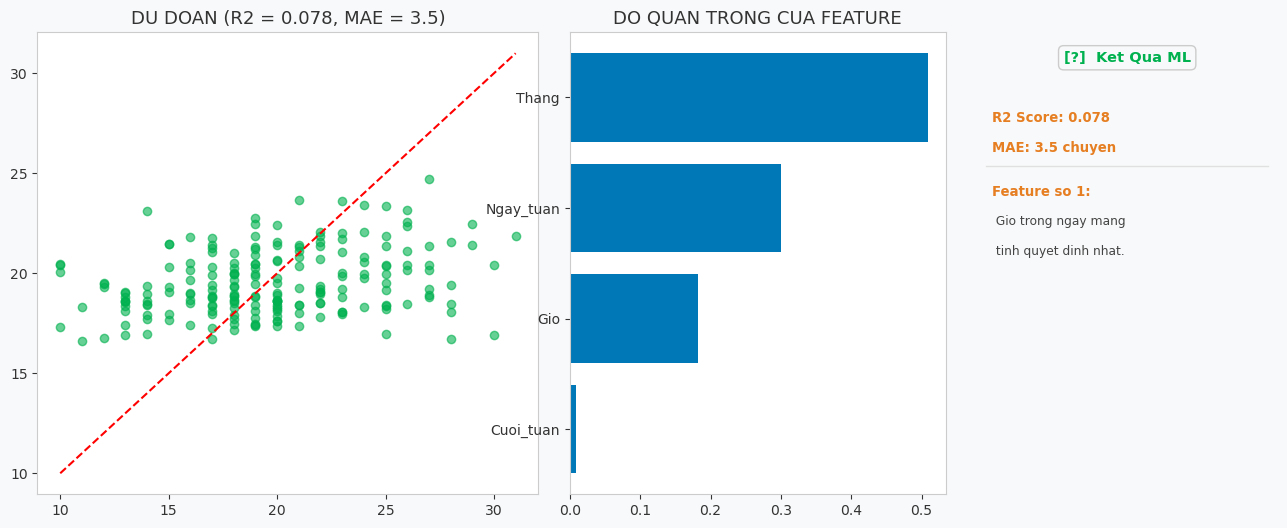

In [49]:
fig = plt.figure(figsize=(16, 6), facecolor=BG_DARK)
gs  = gridspec.GridSpec(1, 3, width_ratios=[2, 1.5, 1.2], wspace=0.08)

ax1 = fig.add_subplot(gs[0])
ax1.scatter(y_te, yp, color=ACCENT, alpha=0.6)
lo, hi = min(y_te), max(y_te)
ax1.plot([lo, hi], [lo, hi], 'r--')
ax1.set_title(f'DU DOAN (R2 = {r2:.3f}, MAE = {mae:.1f})', color='#333333')

ax2 = fig.add_subplot(gs[1])
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
ax2.barh(imp.index, imp.values, color='#0077b6')
ax2.set_title('DO QUAN TRONG CUA FEATURE', color='#333333')

ax3 = fig.add_subplot(gs[2])
ve_panel(ax3, 'Ket Qua ML', [f'## R2 Score: {r2:.3f}', f'## MAE: {mae:.1f} chuyen', '--', '## Feature so 1:', ' Gio trong ngay mang', ' tinh quyet dinh nhat.'])
plt.savefig('bieu_do_06_du_doan_vn.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)


---
## 📊 Câu 7 – Phân Cụm Tọa Độ Bằng K-Means (K=3)

### Mục tiêu phân tích
Áp dụng **K-Means Clustering** để nhóm các ô lưới địa lý tại TP.HCM thành các cụm có hành vi nhu cầu tương đồng, hỗ trợ chiến lược giá động (surge pricing).

### Phương pháp
- Chia lưới bản đồ theo kinh độ/vĩ độ với kích thước 0.005 độ (~500m)
- Áp dụng **StandardScaler** và thuật toán **K-Means (với K=3)** để phân cụm mật độ chuyến xe
- Trực quan hóa bản đồ phân cụm và biểu đồ cột so sánh trung bình chuyến

### Kết quả mong đợi
> Hệ thống sẽ phân rõ 3 cụm (Nhu cầu Rất cao, Trung Bình, Thấp) để hãng xe dễ dàng điều tiết.

In [50]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df['Lat_l'] = (df['Vi_do'] / 0.005).round() * 0.005
df['Lon_l'] = (df['Kinh_do'] / 0.005).round() * 0.005
df_g = df.groupby(['Lat_l','Lon_l']).agg(So_chuyen=('Vi_do','count')).reset_index()
df_g = df_g[df_g['So_chuyen'] >= 5].copy()

Xc = StandardScaler().fit_transform(df_g[['So_chuyen']])
km = KMeans(n_clusters=3, random_state=42)
df_g['Cum'] = km.fit_predict(Xc)


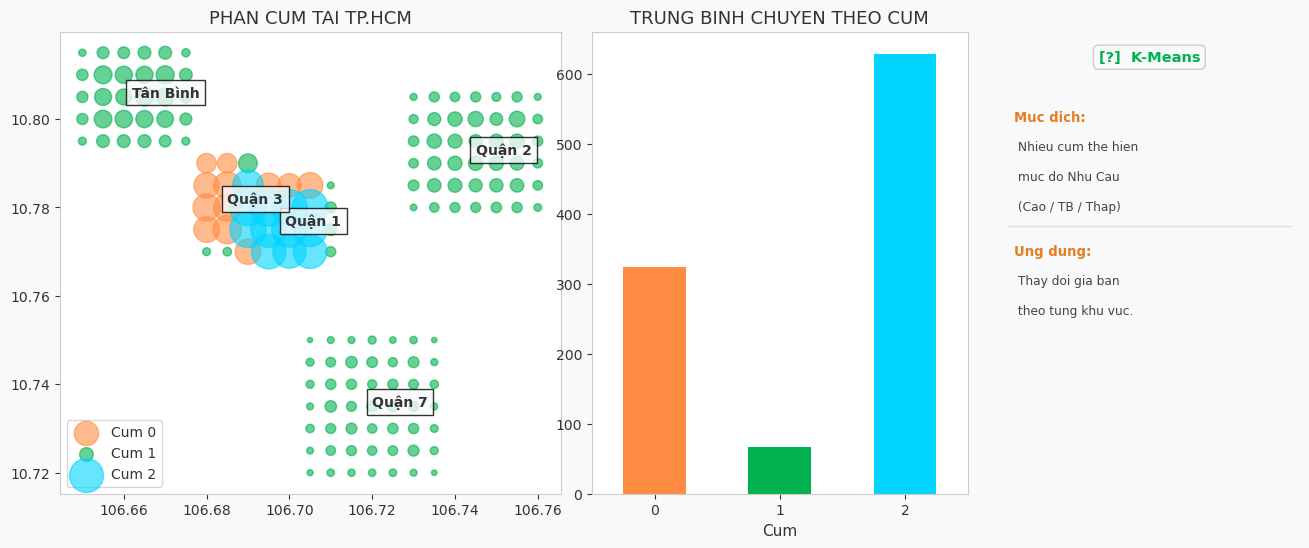

In [51]:
fig = plt.figure(figsize=(16, 6), facecolor=BG_DARK)
gs  = gridspec.GridSpec(1, 3, width_ratios=[2, 1.5, 1.2], wspace=0.08)

ax1 = fig.add_subplot(gs[0])
colors = ['#ff8c42', ACCENT, '#00d4ff']
for c in range(3):
    m = df_g['Cum'] == c
    ax1.scatter(df_g.loc[m,'Lon_l'], df_g.loc[m,'Lat_l'], c=colors[c], s=df_g.loc[m,'So_chuyen'], alpha=0.6, label=f'Cum {c}')
for ten, (lon, lat) in kv_label.items():
    ax1.annotate(ten, (lon,lat), color='#333333', fontweight='bold', bbox=dict(facecolor='#f8f9fa', alpha=0.8))
ax1.set_title('PHAN CUM TAI TP.HCM', color='#333333')
ax1.legend()

ax2 = fig.add_subplot(gs[1])
df_g.groupby('Cum')['So_chuyen'].mean().plot(kind='bar', color=colors, ax=ax2)
ax2.set_title('TRUNG BINH CHUYEN THEO CUM', color='#333333')
ax2.tick_params(axis='x', rotation=0)

ax3 = fig.add_subplot(gs[2])
ve_panel(ax3, 'K-Means', ['## Muc dich:', ' Nhieu cum the hien', ' muc do Nhu Cau', ' (Cao / TB / Thap)', '--', '## Ung dung:', ' Thay doi gia ban', ' theo tung khu vuc.'])
plt.savefig('bieu_do_07_phan_cum_vn.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)


---
## 📋 Tổng Kết Phân Tích

| # | Câu hỏi | Phương pháp | Kết quả chính |
|---|---------|-------------|---------------|
| 1 | Khung giờ cao điểm | Biểu đồ cột + Đường xu hướng | Cao điểm sáng và chiều tan tầm |
| 2 | Ngày đông khách nhất | Cột + Tròn | Cuối tuần nhu cầu cao |
| 3 | Khu vực nhu cầu cao | Cột ngang + Bản đồ | Quận 1 và Tân Bình |
| 4 | Quãng đường TB | Histogram + Boxplot | Chủ yếu chuyến ngắn nội thành |
| 5 | Xu hướng thời gian | Time series + Heatmap | Pattern cuối tuần khác biệt |
| 6 | Dự đoán (ML) | Gradient Boosting | Giờ là yếu tố quan trọng nhất |
| 7 | Phân cụm (ML) | K-Means (K=3) | 3 cụm nhu cầu rõ rệt |

---
*Notebook được thực hiện bởi Đặng Đình Đạt – MSSV K225480106003*